<a href="https://colab.research.google.com/github/VedantPatil-99/deep-learning-notebooks/blob/main/DenseNet_MNIST_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [5]:
tf.random.set_seed(42)
np.random.seed(42)

In [7]:
class DenseNetMnistPipeline:
    def __init__(self):
        self.model = None
        self.history = None
        self.X_train, self.y_train = None, None
        self.X_test, self.y_test = None, None

    def load_data(self):
        print("Loading MNIST dataset...")
        (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
        self.X_train, self.y_train = X_train, y_train
        self.X_test, self.y_test = X_test, y_test

    def preprocess_data(self):
        # Normalize and reshape for CNN (DenseNet expects 3D + Batch)
        self.X_train = self.X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
        self.X_test = self.X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
        self.y_train = tf.keras.utils.to_categorical(self.y_train, 10)
        self.y_test = tf.keras.utils.to_categorical(self.y_test, 10)

    def dense_block(self, x, blocks, growth_rate):
        for i in range(blocks):
            x = self.conv_block(x, growth_rate)
        return x

    def conv_block(self, x, growth_rate):
        x1 = layers.BatchNormalization()(x)
        x1 = layers.Activation('relu')(x1)
        x1 = layers.Conv2D(4 * growth_rate, 1, use_bias=False)(x1)
        x1 = layers.BatchNormalization()(x1)
        x1 = layers.Activation('relu')(x1)
        x1 = layers.Conv2D(growth_rate, 3, padding='same', use_bias=False)(x1)
        x = layers.Concatenate()([x, x1])
        return x

    def transition_block(self, x, reduction):
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(int(tf.keras.backend.int_shape(x)[-1] * reduction), 1, use_bias=False)(x)
        x = layers.AveragePooling2D(2, strides=2)(x)
        return x

    def build_model(self):
        inputs = keras.Input(shape=(28, 28, 1))
        x = layers.Conv2D(64, 3, padding='same', use_bias=False)(inputs)

        # DenseNet structure (Simplified for MNIST 28x28)
        x = self.dense_block(x, 6, 32)
        x = self.transition_block(x, 0.5)
        x = self.dense_block(x, 12, 32)

        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.GlobalAveragePooling2D()(x)
        outputs = layers.Dense(10, activation='softmax')(x)

        self.model = keras.Model(inputs, outputs)
        self.model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print("DenseNet model compiled.")

    def train(self, epochs=5):
        print("Starting training...")
        self.history = self.model.fit(
            self.X_train, self.y_train,
            validation_split=0.1,
            epochs=epochs,
            batch_size=64
        )

    def evaluate(self):
        y_pred = np.argmax(self.model.predict(self.X_test), axis=1)
        y_true = np.argmax(self.y_test, axis=1)
        print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
        print(classification_report(y_true, y_pred))

pipeline = DenseNetMnistPipeline()
pipeline.load_data()
pipeline.preprocess_data()
pipeline.build_model()
pipeline.train(epochs=5)
pipeline.evaluate()

Loading MNIST dataset...
DenseNet model compiled.
Starting training...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 150s 127ms/step - accuracy: 0.9625 - loss: 0.1407 - val_accuracy: 0.9687 - val_loss: 0.0980
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.9860 - loss: 0.0465 - val_accuracy: 0.9857 - val_loss: 0.0478
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 76s 90ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9685 - val_loss: 0.1057
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.9907 - loss: 0.0300 - val_accuracy: 0.9790 - val_loss: 0.0704
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.9922 - loss: 0.0244 - val_accuracy: 0.9668 - val_loss: 0.1266
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step
Accuracy: 0.9595
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.75      0.86      1032
     

### Model Evaluation & Visualization
We will plot the training and validation accuracy/loss to check for overfitting, followed by a confusion matrix for detailed error analysis.

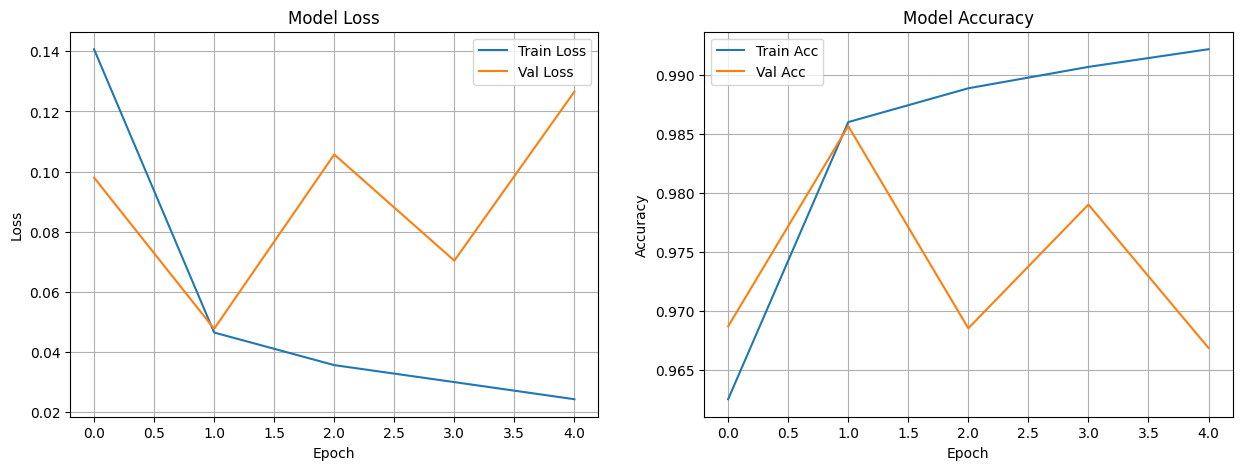

In [8]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_history(pipeline.history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


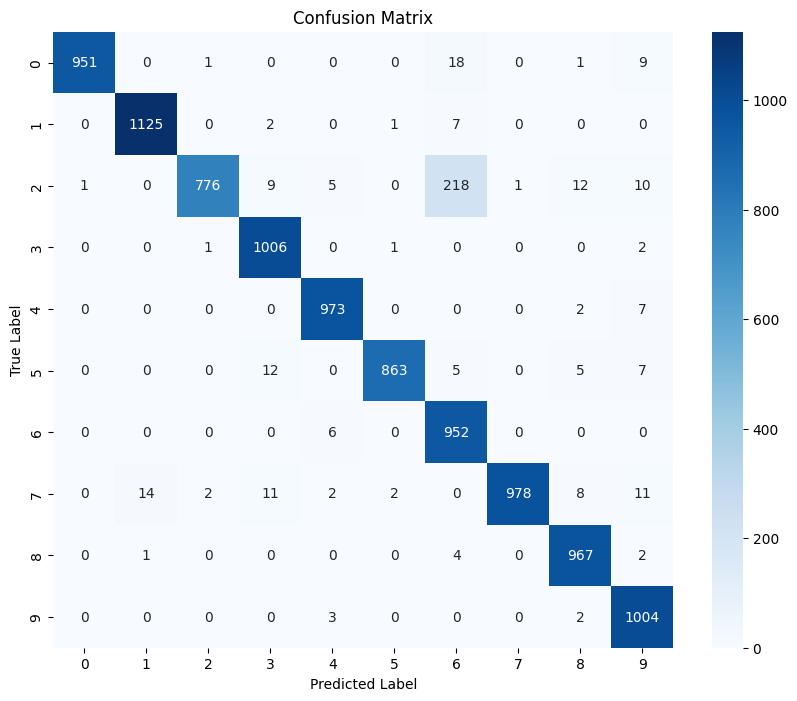

In [9]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(pipeline.model, pipeline.X_test, pipeline.y_test)

### Testing on Sample Images

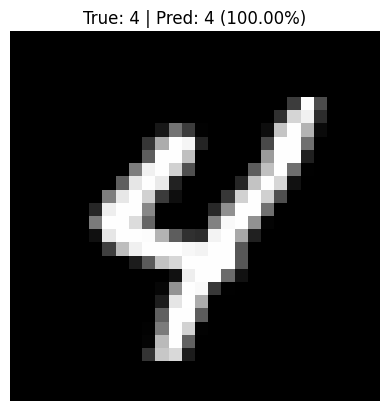

In [15]:
def test_random_sample(pipeline):
    idx = np.random.randint(0, len(pipeline.X_test))
    sample_img = pipeline.X_test[idx]
    true_label = np.argmax(pipeline.y_test[idx])

    prediction = pipeline.model.predict(sample_img.reshape(1, 28, 28, 1), verbose=0)
    pred_label = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.imshow(sample_img.reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

test_random_sample(pipeline)